In [1]:
# Install required dependencies
!pip install -U "bitsandbytes>=0.46.1" transformers accelerate
# !pip uninstall -U "sentence-transformers==3.0.1"
# !pip install -U sentence-transformers
!pip install -q scikit-learn
# !pip uninstall -y torchcodec
!pip install -q torch pillow
!pip install -q uvicorn starlette
!pip install -q mcp langchain-mcp-adapters langgraph langchain-openai
!pip install -q vllm
!pip install "a2a-sdk<1.0"
!pip install google-adk
# !pip install nvidia-nvjitlink-cu12 -q
# !pip install python-a2a 
# For Flask-based server support
# !pip install "python-a2a[server]"
# Note: The A2A SDK would need to be installed. If not publicly available on PyPI, 
# you might need to install it from a local directory or private repo.
# !pip install --upgrade google-adk
# !pip install \
#   "opentelemetry-sdk==1.38.0" \
#   "opentelemetry-api==1.38.0" \
#   "opentelemetry-proto==1.38.0" \
#   "opentelemetry-exporter-otlp==1.38.0" \
#   "opentelemetry-exporter-otlp-proto-http==1.38.0" \
#   "opentelemetry-exporter-otlp-proto-grpc==1.38.0" \
#   "opentelemetry-exporter-otlp-proto-common==1.38.0"
!pip install \
  "opentelemetry-sdk==1.41.1" \
  "opentelemetry-api==1.41.1" \
  "opentelemetry-proto==1.41.1" \
  "opentelemetry-exporter-otlp==1.41.1" \
  "opentelemetry-exporter-otlp-proto-http==1.41.1" \
  "opentelemetry-exporter-otlp-proto-grpc==1.41.1" \
  "opentelemetry-exporter-otlp-proto-common==1.41.1"

# !pip install -q a2a-python-sdk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 170.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 51.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.2/248.2 MB 3.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 MB 3.8 MB/s eta 0:00

In [2]:
!echo "/usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib" \
    > /etc/ld.so.conf.d/nvjitlink-cu13.conf
!ldconfig

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero_v2.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtc

In [3]:
!ldconfig -p | grep "nvJitLink.so.13"
# Must output something like:
# libnvJitLink.so.13 => /usr/local/lib/python3.12/.../libnvJitLink.so.13

	libnvJitLink.so.13 (libc6,x86-64) => /usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib/libnvJitLink.so.13


In [4]:
import os
import getpass
from huggingface_hub import login

hf_token = getpass.getpass("Enter your Hugging Face token: ")
login(token=hf_token)

In [6]:
import os
print(os.listdir())

['.config', 'orchestrator_agent', 'specialist_agent', 'knowledge_server', 'knowledge_base_H&R.json', 'sample_data']


In [7]:
# # What CUDA does your system have?
# !nvcc --version

# # What bitsandbytes version is installed?
# !pip show bitsandbytes

# # What PyTorch CUDA version?
# import torch
# print(torch.__version__)
# print(torch.version.cuda)

# # Does the file exist anywhere?
# !find / -name "libnvJitLink.so*" 2>/dev/null

In [8]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model_id = "google/medgemma-1.5-4b-it"
medgemma_processor = AutoProcessor.from_pretrained(model_id)
medgemma_model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    quantization_config=quant_config,
    # dtype=torch.bfloat16,
    device_map="auto",
)
print("✅ MedGemma loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

✅ MedGemma loaded successfully!


In [9]:
!python -c "import a2a; print('A2A SDK imported successfully')"

A2A SDK imported successfully


In [10]:
!pip show a2a-sdk

Name: a2a-sdk
Version: 0.3.26
Summary: A2A Python SDK
Home-page: https://a2a-protocol.org/
Author: 
Author-email: Google LLC <googleapis-packages@google.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: google-api-core, httpx, httpx-sse, protobuf, pydantic
Required-by: 


In [11]:
# Quick import test
from a2a.server.apps import A2AStarletteApplication
from a2a.server.agent_execution import AgentExecutor
print("✅ Correct a2a-sdk is installed!")

✅ Correct a2a-sdk is installed!


In [12]:
import threading
import uvicorn
from specialist_agent.a2a_server import create_a2a_app

# Create the A2A app with the loaded MedGemma model
a2a_app = create_a2a_app(medgemma_model, medgemma_processor)

def start_a2a_server():
    config = uvicorn.Config(a2a_app, host="127.0.0.1", port=8001, log_level="error")
    server = uvicorn.Server(config)
    server.run()

# Run the server in a background thread so the notebook isn't blocked
a2a_thread = threading.Thread(target=start_a2a_server, daemon=True)
a2a_thread.start()
print("A2A Specialist Server running on http://127.0.0.1:8001")


[MedGemma] pipeline ready on device=cuda:0 dtype=torch.bfloat16
A2A Specialist Server running on http://127.0.0.1:8001


In [13]:
!nohup python -m vllm.entrypoints.openai.api_server \
    --model google/gemma-4-E2B-it \
    --port 8000 \
    --dtype bfloat16 \
    --gpu-memory-utilization 0.6 \
    --max-model-len 4096 \
    --trust-remote-code \
    --enable-auto-tool-choice \
    --tool-call-parser gemma4 \
    --reasoning-parser gemma4 > vllm.log 2>&1 &

In [27]:
# Run this to peek at the server logs and see if it says "Application startup complete"
!tail -n 20 vllm.log

(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /ping, Methods: GET
(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /ping, Methods: POST
(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /invocations, Methods: POST
(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /v1/chat/completions, Methods: POST
(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /v1/chat/completions/batch, Methods: POST
(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /v1/responses, Methods: POST
(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /v1/responses/{response_id}, Methods: GET
(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /v1/responses/{response_id}/cancel, Methods: POST
(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /v1/completions, Methods: POST
(APIServer pid=6903) INFO 05-18 21:59:14 [launcher.py:46] Route: /v1/messages, Methods: POST
(APIServer pid=6903) IN

### Start Gemma 4 E2B Server
Run the following command in the **Colab terminal** (or a separate cell with `!`) to start the OpenAI-compatible server for Gemma 4. 
*Note: Depending on VRAM, you might need to run this with specific quantization flags.*

```bash
python -m vllm.entrypoints.openai.api_server --model google/gemma-4-E2B-it --port 8000 --quantization bitsandbytes --load-format bitsandbytes
```


In [28]:
import asyncio
from langchain_openai import ChatOpenAI
from langchain_mcp_adapters.client import MultiServerMCPClient
from orchestrator_agent.graph import create_diagnosis_graph, create_initial_state
import os

# Connect to the local vLLM server
llm = ChatOpenAI(
    model="google/gemma-4-E2B-it",
    openai_api_key="EMPTY", # vLLM doesn't require a real key
    openai_api_base="http://localhost:8000/v1",
    temperature=0.2
)

# Configure MCP server over SSE (stable for notebook runtimes)
mcp_config = {
    "hr_knowledge_base": {
        "transport": "sse",
        "url": "http://127.0.0.1:8002/sse"
    }
}

async def setup_graph():
    # Initialize the MultiServerMCPClient to dynamically fetch tools
    client = MultiServerMCPClient(mcp_config)
    
    mcp_tools = await client.get_tools()
    print(f"Loaded {len(mcp_tools)} MCP tools: {[t.name for t in mcp_tools]}")
    warm_tool = next((tool for tool in mcp_tools if tool.name == "warm_semantic_index"), None)
    if warm_tool is not None:
        print("Warming semantic index on the MCP server...")
        print(await warm_tool.ainvoke({}))
    
    # Create the LangGraph orchestrator
    graph = create_diagnosis_graph(llm, mcp_tools)
    return graph, client

# We will initialize this in the main async function below


✅ Successfully downloaded and saved sample_lesion.jpg


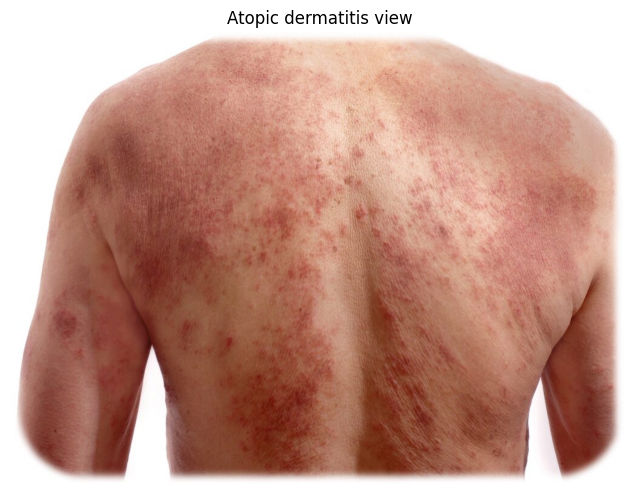

In [29]:
from io import BytesIO
import matplotlib.pyplot as plt
from PIL import Image
import requests

# 3. Create a test image for consult_specialist
try:
  image_url = "https://uniontherapeutics.com/wp-content/uploads/2021/12/ad2-1024x746.jpg"    
  response = requests.get(image_url, headers={"User-Agent": "tutorial"})
  image = Image.open(BytesIO(response.content))
  image.save('sample_lesion.jpg')
  print("✅ Successfully downloaded and saved sample_lesion.jpg")
  plt.figure(figsize=(8, 8))
  plt.imshow(image, cmap='gray')
  plt.axis('off')
  plt.title('Atopic dermatitis view')
  plt.show()
  # print("Successfully created sample_lesion.jpg")
except Exception as e:
    print("image has not been uploaded: {e}")

In [30]:
os.listdir()

['.config',
 'vllm.log',
 'orchestrator_agent',
 'specialist_agent',
 'knowledge_server',
 'knowledge_base_H&R.json',
 'sample_lesion.jpg',
 'sample_data']

In [31]:
import os
import time

# 1. Kill any frozen "zombie" servers holding port 8002
os.system("pkill -f mcp_server.py")
print("🧹 Cleared old background servers.")

# 2. Check if the Knowledge Base actually exists in Colab!
if not os.path.exists('knowledge_base_H&R.json'):
    print("❌ ERROR: 'knowledge_base_H&R.json' is MISSING from your main folder!")
    print("👉 Please drag-and-drop it into the Colab file explorer before continuing.")
else:
    print("✅ Knowledge Base JSON found.")
    print("🚀 Launching fresh MCP Server over SSE...")
    
    # 3. Launch it cleanly
    os.system("nohup python knowledge_server/mcp_server.py --sse > mcp_server.log 2>&1 &")
    
    # Wait for the web server to initialize
    time.sleep(4)
    
    # 4. Print the exact server log so we can see if it worked
    print("\n--- MCP SERVER LOG ---")
    os.system("cat mcp_server.log")

🧹 Cleared old background servers.
✅ Knowledge Base JSON found.
🚀 Launching fresh MCP Server over SSE...

--- MCP SERVER LOG ---


In [32]:
%cat mcp_server.log

INFO:     Started server process [9269]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8002 (Press CTRL+C to quit)


In [33]:
from langchain_core.messages import HumanMessage, AIMessage
from langchain_mcp_adapters.client import MultiServerMCPClient
import asyncio

# --- 1. THE FIX: Change transport to SSE and point to the localhost URL ---
mcp_config = {
    "hr_knowledge_base": {
        "transport": "sse",
        "url": "http://127.0.0.1:8002/sse"
    }
}

def _patient_wants_to_stop(answer):
    normalized = (answer or "").strip().lower()
    stop_phrases = {
        "stop",
        "done",
        "that is all",
        "that's all",
        "thats all",
        "no more",
        "i don't know",
        "i dont know",
        "not sure",
        "skip",
    }
    return normalized in stop_phrases

# NOTE: REAL FILE UPDATED - graph-driven stop conditions, no for-loop guardrail.
async def run_diagnosis(patient_text=None, image_path=None, show_debug=False):
    print("Setting up Orchestrator Graph...")
    graph, mcp_client = await setup_graph()
    
    print("\n--- NEW MULTI-TURN SESSION (GRAPH-DRIVEN STOP) ---")
    if patient_text is None:
        patient_text = input("Patient: Please describe the rash and symptoms: ").strip()
    if not patient_text:
        print("A symptom description is required to start the interview.")
        return None
    
    if image_path is None:
        image_path = input("Patient: Image path [sample_lesion.jpg or blank for none]: ").strip()
    image_path = (image_path or "").strip()
    
    state = create_initial_state(patient_text=patient_text, image_path=image_path)
    print(f"\nPatient Input: {patient_text}")
    print(f"Image provided at: {image_path or 'None'}\n")
    
    while True:
        state = await graph.ainvoke(state)
        assistant_msg = next((msg for msg in reversed(state["messages"]) if isinstance(msg, AIMessage)), None)
        if assistant_msg is None:
            print("No assistant response returned.")
            return state
    
        turn_label = state.get("turn_count", 0)
        print(f"\n--- Turn {turn_label} ---")
        print(assistant_msg.content)
    
        if show_debug:
            print(f"\nInterview status: {state.get('interview_status')}")
            print(f"Open questions: {state.get('open_questions')}")
            print(f"Stalled turns: {state.get('stalled_turns')}")
            print(f"Topic attempts: {state.get('topic_attempts')}")
            print(f"Stop reason: {state.get('stop_reason')}")
    
        if state.get("interview_status") in {"ready_to_conclude", "conclude_with_uncertainty"}:
            print("\nConversation complete.")
            return state
    
        answer = input("Patient: ").strip()
        if not answer:
            answer = "I do not want to answer more questions. Please conclude with the current information."
        elif _patient_wants_to_stop(answer):
            answer = "I do not know anything else and want you to conclude with the current information."
        state["messages"].append(HumanMessage(content=answer))
        if "conclude with the current information" in answer.lower():
            state["interview_status"] = "conclude_with_uncertainty"
            state["stop_reason"] = "patient_stopped"



In [34]:
import importlib
import orchestrator_agent.graph as graph_mod
importlib.reload(graph_mod)

<module 'orchestrator_agent.graph' from '/content/orchestrator_agent/graph.py'>

In [35]:
create_diagnosis_graph = graph_mod.create_diagnosis_graph
create_initial_state = graph_mod.create_initial_state


In [36]:
print("Semantic warmup now happens inside setup_graph() through the MCP server.")

Semantic warmup now happens inside setup_graph() through the MCP server.


In [37]:
# Fire it off!
await run_diagnosis()

Setting up Orchestrator Graph...
Loaded 7 MCP tools: ['get_major_criteria', 'get_minor_criteria', 'get_grading_rules', 'search_criteria', 'warm_semantic_index', 'score_patient_history', 'score_specialist_findings']
Warming semantic index on the MCP server...
[{'type': 'text', 'text': 'Semantic index warmed and ready.', 'id': 'lc_ebff9e37-087d-4260-b794-c8196d59eadb'}]

--- NEW MULTI-TURN SESSION (GRAPH-DRIVEN STOP) ---


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



Patient Input: I have very itchy rash on my back
Image provided at: sample_lesion.jpg



[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



--- Turn 1 ---
1. We know you have an itchy rash on your back, and the specialist observed a widespread rash composed of small, red papules and macules on your back without obvious scaling or crusting.
2. How intense is the itching, and does it keep coming back or disturb your sleep?

--- Turn 2 ---
1. I am asking about the severity of your itching and whether the rash recurs or disrupts your sleep, as this helps determine if the condition is chronic.
2. Does the itching become severe enough to interfere with your sleep, and has this rash appeared before?

--- Turn 3 ---
1. We now know you have a very itchy rash on your back, which is severe enough to keep you awake, and the specialist noted a widespread rash of small red papules and macules on your back.
2. Have you noticed any dryness, flaking, or tightness in your skin, especially in dry areas like your elbows or around your mouth?

--- Turn 4 ---
1. We have gathered information that you have a very itchy rash on your back, which i

{'messages': [HumanMessage(content='Patient Input: I have very itchy rash on my back\nImage provided at: sample_lesion.jpg', additional_kwargs={}, response_metadata={}),
  AIMessage(content='1. We know you have an itchy rash on your back, and the specialist observed a widespread rash composed of small, red papules and macules on your back without obvious scaling or crusting.\n2. How intense is the itching, and does it keep coming back or disturb your sleep?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 1040, 'total_tokens': 1101, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-4-E2B-it', 'system_fingerprint': 'vllm-0.21.0-ad6966b7', 'id': 'chatcmpl-a634064cd00b4b46', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3d1c-6819-7031-983d-9624e8ec185f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1040, 'outpu